# Preprocessing
### Load non-binary affinity CSV

In [2]:
import pandas as pd
import os

def load_csv_to_memory(file_path):
    """
    Loads a CSV file into a Pandas DataFrame in memory.
    Returns the DataFrame object if successful, or None if it fails.
    """
    # 1. Verify the file exists
    if not os.path.isfile(file_path):
        print(f"Error: The file '{file_path}' was not found.")
        return None

    # 2. Attempt to read the CSV file into memory
    try:
        df = pd.read_csv(file_path)
        print(f"Successfully loaded '{os.path.basename(file_path)}' into memory.")
        return df
        
    # Handle the specific case where the file exists but has no data
    except pd.errors.EmptyDataError:
        print("Error: The CSV file is completely empty.")
        return None
        
    # Handle any other unexpected errors (e.g., permission issues)
    except Exception as e:
        print(f"An unexpected error occurred while loading the CSV: {e}")
        return None

# --- Example Usage ---
if __name__ == "__main__":
    # Replace with the actual path to your general CSV file!!!
    target_csv_path = r"/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/part-00000-8c1c6711-06a2-4792-8f2c-3341b1499d6f-c000.csv"
    
    # The variable 'my_dataframe' now holds the data in memory
    my_dataframe = load_csv_to_memory(target_csv_path)
    
    # Verify it loaded correctly by printing some basic information
    if my_dataframe is not None:
        print("\n--- DataFrame Summary ---")
        print(f"Total Rows: {len(my_dataframe)}")
        print(f"Total Columns: {len(my_dataframe.columns)}")
        
        print("\nFirst 3 rows:")
        print(my_dataframe.head(3))

/tmp/ipykernel_945664/234795479.py:16: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Successfully loaded 'part-00000-8c1c6711-06a2-4792-8f2c-3341b1499d6f-c000.csv' into memory.

--- DataFrame Summary ---
Total Rows: 816756
Total Columns: 10

First 3 rows:
  dataset                                     heavy_sequence light_sequence  \
0  biomap  ADLVQSGAVVKKPGDSVRISCEAQGYRFPDYIIHWIRRAPGQGPEW...            NaN   
1  biomap  AEVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGL...            NaN   
2  biomap  ASVLSEVQLQQSGPELVKPGASVKLSCKTSENTFTEYTMHWVKQSH...            NaN   

    scfv affinity_type affinity  \
0  False       delta_g    -12.4   
1  False       delta_g    -12.7   
2  False       delta_g    -11.8   

                                    antigen_sequence confidence  nanobody  \
0  VWKDADTTLFCASDAKAHETEVHNVWATHACVPTDPNPQEIHLENV...  very_high     False   
1  TSRVKPDPPHIKNLSFHNDDLYVQWENPQNFISRCLFYEVEVNNSQ...  very_high     False   
2  MIRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIEL...  very_high     False   

  processed_measurement  
0                 -12.4  
1         

In [3]:
# Assuming your loaded dataframe from Cell 1 is named 'my_dataframe'
# If you named it something else (like 'df'), update the variable name below
df = my_dataframe

# 1. Number of unique entries in 'antigen_sequence'
unique_antigens = df['antigen_sequence'].nunique()

# 2. Number of unique entries in 'dataset'
unique_datasets = df['dataset'].nunique()

# 3. Find rows with the same 'antigen_sequence' but different 'dataset' entries
# Count how many unique datasets each antigen_sequence belongs to
dataset_counts_per_seq = df.groupby('antigen_sequence')['dataset'].nunique()

# Filter down to only the sequences that appear in more than one dataset
overlapping_seqs = dataset_counts_per_seq[dataset_counts_per_seq > 1].index

# Filter the original dataframe to get the actual rows containing these overlapping sequences
overlapping_rows = df[df['antigen_sequence'].isin(overlapping_seqs)]
num_overlapping_rows = len(overlapping_rows)

# Print the results
print("--- Dataset Summary ---")
print(f"Unique 'antigen_sequence' entries: {unique_antigens}")
print(f"Unique 'dataset' entries: {unique_datasets}")
print(f"\n--- Overlap Analysis ---")
print(f"Number of unique sequences spanning multiple datasets: {len(overlapping_seqs)}")
print(f"Total number of rows containing these overlapping sequences: {num_overlapping_rows}")

--- Dataset Summary ---
Unique 'antigen_sequence' entries: 639
Unique 'dataset' entries: 16

--- Overlap Analysis ---
Number of unique sequences spanning multiple datasets: 19
Total number of rows containing these overlapping sequences: 529187


### Assign universal and library IDs

In [4]:
import os
import pandas as pd

# Assuming the dataframe from your initial load cell is 'my_dataframe'
# and your original file path variable is still 'target_csv_path'
df = my_dataframe.copy() 

# 1. Verify the required columns exist
required_cols = ['heavy_sequence', 'light_sequence', 'dataset', 'antigen_sequence']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"Error: The following required columns are missing from the DataFrame: {missing_cols}")
else:
    # 2. Assign sequential IDs based on unique sequence and antigen trios (Universal ID)
    # ngroup() assigns a unique integer (starting at 0) to each group. We add 1 so it starts at 1.
    universal_ids = df.groupby(['heavy_sequence', 'light_sequence', 'antigen_sequence'], sort=False, dropna=False).ngroup() + 1
    df['universal_id'] = universal_ids.astype(str).str.zfill(9)
    
    # 3. Assign sequential IDs based on unique dataset and antigen pairs (Library ID)
    library_ids = df.groupby(['dataset', 'antigen_sequence'], sort=False, dropna=False).ngroup() + 1
    # Padding this one to 6 digits for consistency, adjust zfill() if needed
    df['library_id'] = library_ids.astype(str).str.zfill(6)
    
    # Reorder columns to make 'universal_id' and 'library_id' the very first columns for readability
    cols = ['universal_id', 'library_id'] + [col for col in df.columns if col not in ['universal_id', 'library_id']]
    df = df[cols]

    # 4. Determine the output path based on the original target_csv_path
    base_dir = os.path.dirname(target_csv_path)
    output_path = os.path.join(base_dir, "asd_full_id.csv")

    # 5. Save the dataframe to the new CSV file
    # By default, to_csv will write these string values with their leading zeros perfectly intact
    df.to_csv(output_path, index=False)
    
    print(f"--- ID Assignment Summary ---")
    print(f"Assigned {universal_ids.nunique()} unique Universal IDs (9-digit).")
    print(f"Assigned {library_ids.nunique()} unique Library IDs (6-digit).")
    print(f"Total rows processed: {len(df)}")
    print(f"✅ Saved updated dataset to:\n{output_path}\n")

    # 6. Print the first 5 rows of the new .csv file
    print("--- First 5 rows of the new file ---")
    
    # When reading it back in just to verify, we specify dtype=str for both ID columns so Pandas 
    # doesn't auto-remove the leading zeros before printing them to your screen
    verify_df = pd.read_csv(output_path, nrows=5, dtype={'universal_id': str, 'library_id': str})
    print(verify_df)

    # Update the main variable so subsequent cells have access to the IDs
    my_dataframe = df

--- ID Assignment Summary ---
Assigned 816756 unique Universal IDs (9-digit).
Assigned 666 unique Library IDs (6-digit).
Total rows processed: 816756
✅ Saved updated dataset to:
/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/asd_full_id.csv

--- First 5 rows of the new file ---
  universal_id library_id   dataset  \
0    000000001     000001    biomap   
1    000000002     000002    biomap   
2    000000003     000003    biomap   
3    000000004     000004    biomap   
4    000000005     000005  skempiv2   

                                      heavy_sequence  \
0  ADLVQSGAVVKKPGDSVRISCEAQGYRFPDYIIHWIRRAPGQGPEW...   
1  AEVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGL...   
2  ASVLSEVQLQQSGPELVKPGASVKLSCKTSENTFTEYTMHWVKQSH...   
3  AVKLQESGPGILKPSQTLSLTCSFSGFSLTTAGMGVGWIRQSSGKG...   
4  AVKLQESGPGILKPSQTLSLTCSFSGFSLTTAGMGVGWIRQSSGKG...   

                                      light_sequence   scfv affinity_type  \
0                                                NaN  False    

### Count cross-reactive antibody sequences

In [5]:
import pandas as pd

# Assuming 'my_dataframe' is the variable holding the latest version of your data
df = my_dataframe.copy()

# 1. Verify required columns exist
required_cols = ['heavy_sequence', 'light_sequence', 'antigen_sequence']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"Error: The following required columns are missing: {missing_cols}")
else:
    print("Analyzing sequence-antigen mappings... this might take a moment.")
    
    # 2. Count unique antigens per heavy/light pair
    # .transform('nunique') calculates the number of unique antigens for a group 
    # and maps that integer back to every row belonging to that group.
    unique_antigens_per_pair = df.groupby(
        ['heavy_sequence', 'light_sequence'], dropna=False
    )['antigen_sequence'].transform('nunique')
    
    # 3. Filter for rows where the sequence pair maps to multiple different antigens
    cross_reactive_rows = df[unique_antigens_per_pair > 1]
    
    # 4. Calculate the metrics
    total_cross_reactive_rows = len(cross_reactive_rows)
    
    # Optional: also count how many unique sequence PAIRS do this
    unique_pairs_count = len(cross_reactive_rows[['heavy_sequence', 'light_sequence']].drop_duplicates())
    
    print("\n--- Cross-Reactive Sequence Summary ---")
    print(f"Total rows (with identical heavy/light sequences but different antigens): {total_cross_reactive_rows}")
    print(f"Number of unique heavy/light sequence pairs exhibiting this behavior: {unique_pairs_count}")
    
    # 5. Display a quick preview if any such rows exist
    if total_cross_reactive_rows > 0:
        print("\n--- Preview of these cross-reactive sets ---")
        
        # Determine which columns to show in the preview (safely checking if universal_id exists)
        preview_cols = ['heavy_sequence', 'light_sequence', 'antigen_sequence']
        if 'universal_id' in cross_reactive_rows.columns:
            preview_cols.insert(0, 'universal_id')
            
        # Sort by the sequences so identical pairs appear neatly stacked together in the printout
        preview_df = cross_reactive_rows[preview_cols].sort_values(['heavy_sequence', 'light_sequence']).head(10)
        print(preview_df.to_string(index=False))

Analyzing sequence-antigen mappings... this might take a moment.

--- Cross-Reactive Sequence Summary ---
Total rows (with identical heavy/light sequences but different antigens): 777
Number of unique heavy/light sequence pairs exhibiting this behavior: 95

--- Preview of these cross-reactive sets ---
universal_id                                                                                                                                                                       heavy_sequence light_sequence                                                                                antigen_sequence
   000000026 AVKLQESGPGILKPSQTLSLTCSFSGFSLTTYGMGVGWIRQSSGKGLEWLAHIWWDDDKYYNPSLKSRLTISKDTSRNQVFLKITSVATADTATYYCARRAPFYGNHAMDYWGQGTTVTVSSAKTTPCLVYFPEPVTVTWNSGSSGVHTFPAVLQSDLYTLSSSVTCNVAHPASSTKVDK            NaN SVPTPTNVLIKSYNMNPIVYWEYQIMPQVPVFTVEVKNYGVKNSEWIDACINISHHYCNISDHVGDPSNSLWVRVKARVGQKESAYAKSEEFAVS
   000000027 AVKLQESGPGILKPSQTLSLTCSFSGFSLTTYGMGVGWIRQSSGKGLEWLAHIWWDDDKYYNPSLKSRLTISKD

### Plot library-scale heavy and light sequence length variation

Calculating length distributions across groups... this may take a moment.


/tmp/ipykernel_945664/2734436317.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = df.groupby(['dataset', 'antigen_sequence']).apply(calc_divergence_stats).dropna()


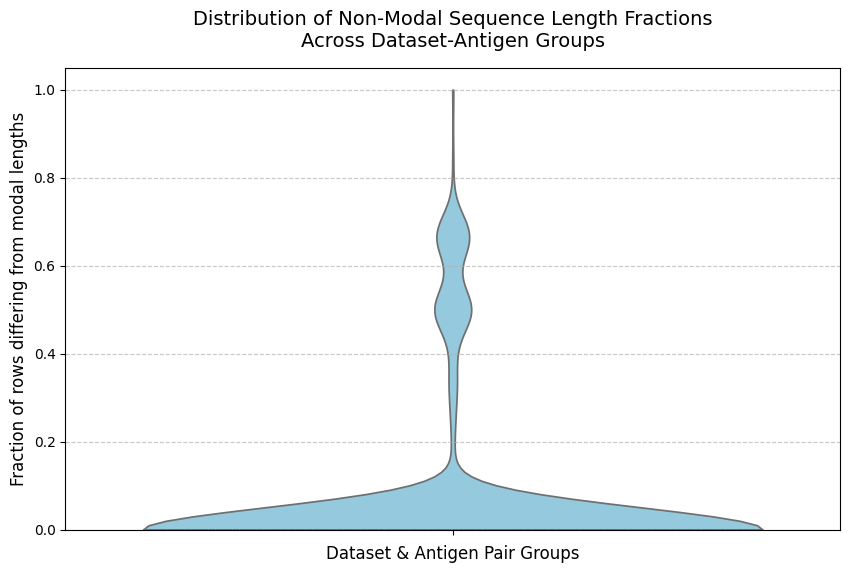

--- Divergence Fraction Summary Statistics ---
count    666.000
mean       0.067
std        0.184
min        0.000
25%        0.000
50%        0.000
75%        0.000
max        1.000

--- Additional Metrics ---
Groups with a divergent fraction > 0: 93
Total rows differing from their group's modal lengths: 25588


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'my_dataframe' is the variable from your ID assignment cell
df = my_dataframe.copy()

# 1. Calculate the lengths of the sequences 
# We use .fillna('') so any blank/missing sequences have a length of 0 instead of causing errors
df['heavy_len'] = df['heavy_sequence'].fillna('').str.len()
df['light_len'] = df['light_sequence'].fillna('').str.len()

# 2. Define a function to calculate the divergence stats for a single group
def calc_divergence_stats(group):
    # Skip entirely empty groups just in case
    if len(group) == 0:
        return pd.Series({'fraction': None, 'divergent_count': 0})
    
    # Find the most common length (mode) for both chains
    heavy_mode = group['heavy_len'].mode()[0]
    light_mode = group['light_len'].mode()[0]
    
    # Identify rows that perfectly match BOTH most common lengths
    matches_both = (group['heavy_len'] == heavy_mode) & (group['light_len'] == light_mode)
    
    # Calculate the absolute count of divergent rows using the bitwise NOT operator (~)
    divergent_count = (~matches_both).sum()
    
    # Calculate the fraction
    fraction_divergent = divergent_count / len(group)
    
    return pd.Series({'fraction': fraction_divergent, 'divergent_count': divergent_count})

# 3. Apply the function to each unique dataset + antigen_sequence pair
print("Calculating length distributions across groups... this may take a moment.")
stats = df.groupby(['dataset', 'antigen_sequence']).apply(calc_divergence_stats).dropna()

# Extract just the fractions for the plot
fractions = stats['fraction']

# 4. Generate the violin plot
plt.figure(figsize=(10, 6))

# Plot the distribution of the fractions
sns.violinplot(y=fractions, color='skyblue', inner='quartile', cut=0)

# Add formatting and labels
plt.title('Distribution of Non-Modal Sequence Length Fractions\nAcross Dataset-Antigen Groups', fontsize=14, pad=15)
plt.ylabel('Fraction of rows differing from modal lengths', fontsize=12)
plt.xlabel('Dataset & Antigen Pair Groups', fontsize=12)

# Ensure the y-axis spans logically from 0 to 1
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

# 5. Print statistical summaries and requested counts
print("--- Divergence Fraction Summary Statistics ---")
print(fractions.describe().round(3).to_string())

# Calculate the new metrics
groups_with_divergence = (fractions > 0).sum()
total_divergent_rows = int(stats['divergent_count'].sum())

print("\n--- Additional Metrics ---")
print(f"Groups with a divergent fraction > 0: {groups_with_divergence}")
print(f"Total rows differing from their group's modal lengths: {total_divergent_rows}")

### Add boolean for variants with nonmodal sequence lengths

In [7]:
import pandas as pd

# Assuming 'my_dataframe' is the variable holding your current data
df = my_dataframe.copy()

# 1. Verify required columns exist
required_cols = ['library_id', 'heavy_sequence', 'light_sequence']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"Error: The following required columns are missing: {missing_cols}")
else:
    print("Calculating modal lengths and assigning boolean flags... this may take a moment.")
    
    # 2. Temporarily calculate and store the sequence lengths
    # .fillna('') ensures any blank entries are safely treated as length 0
    df['temp_h_len'] = df['heavy_sequence'].fillna('').str.len()
    df['temp_l_len'] = df['light_sequence'].fillna('').str.len()
    
    # 3. Group by library_id and find the most common (modal) length for each chain
    # The lambda grabs the first mode [0] to safely resolve any perfect ties
    library_modes = df.groupby('library_id')[['temp_h_len', 'temp_l_len']].agg(
        lambda x: x.mode()[0] if not x.mode().empty else 0
    )
    
    # Rename these columns so they don't clash when we map them back to the main dataframe
    library_modes = library_modes.rename(columns={
        'temp_h_len': 'modal_h_len', 
        'temp_l_len': 'modal_l_len'
    })
    
    # 4. Merge the modal lengths back onto every row based on their library_id
    df = df.merge(library_modes, left_on='library_id', right_index=True, how='left')
    
    # 5. Create the boolean column
    # Evaluates to True if BOTH the heavy and light lengths match the library's mode, otherwise False
    df['modal_length'] = (df['temp_h_len'] == df['modal_h_len']) & (df['temp_l_len'] == df['modal_l_len'])
    
    # 6. Clean up the temporary calculation columns to keep the dataframe tidy
    df = df.drop(columns=['temp_h_len', 'temp_l_len', 'modal_h_len', 'modal_l_len'])
    
    # 7. Output a summary of the results
    true_count = df['modal_length'].sum()
    false_count = (~df['modal_length']).sum()
    
    print("\n--- Modal Length Flag Summary ---")
    print(f"Total rows evaluated: {len(df)}")
    print(f"✅ modal_length = True  (Matches library mode):  {true_count}")
    print(f"❌ modal_length = False (Differs from mode):     {false_count}")

    df.to_csv(output_path, index=False)

    # Update the main variable so subsequent cells have access to the new boolean column
    my_dataframe = df

Calculating modal lengths and assigning boolean flags... this may take a moment.

--- Modal Length Flag Summary ---
Total rows evaluated: 816756
✅ modal_length = True  (Matches library mode):  791168
❌ modal_length = False (Differs from mode):     25588


### Create simplified ID to multimer mapping parent .csv

In [8]:
import os
import pandas as pd

# Assuming the dataframe from the ID assignment cell is still 'my_dataframe'
# and your original file path variable is still 'target_csv_path'
df = my_dataframe

# 1. Define the exact columns you want to isolate
cols_to_keep = [
    'universal_id',
    'library_id',
    'heavy_sequence', 
    'light_sequence', 
    'antigen_sequence',
    'scfv',
    'nanobody',
    'modal_length'
]

# 2. Verify all these columns actually exist in the dataframe
missing_cols = [col for col in cols_to_keep if col not in df.columns]

if not missing_cols:
    
    # 3. Create a new dataframe containing only the desired columns
    df_subset = df[cols_to_keep]
    
    # 4. Determine the output path based on the original target_csv_path
    base_dir = os.path.dirname(target_csv_path)
    output_path = os.path.join(base_dir, "asd_seq_id.csv")
    
    # 5. Save the subset dataframe to the new CSV file
    df_subset.to_csv(output_path, index=False)
    
    print("--- Sequence ID Extraction Summary ---")
    print(f"Extracted {len(cols_to_keep)} columns across {len(df_subset)} rows.")
    print(f"✅ Saved condensed dataset to:\n{output_path}\n")
    
    # 6. Print the first few rows to verify the output visually
    print("--- First 3 rows of the new file ---")
    # Using dtype={'universal_id': str} to ensure Pandas prints the leading zeros
    verify_df = pd.read_csv(output_path, nrows=3, dtype={'universal_id': str, 'library_id': str})
    print(verify_df)

else:
    print(f"Error: Could not extract data. The following columns are missing: {missing_cols}")

--- Sequence ID Extraction Summary ---
Extracted 8 columns across 816756 rows.
✅ Saved condensed dataset to:
/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/asd_seq_id.csv

--- First 3 rows of the new file ---
  universal_id library_id                                     heavy_sequence  \
0    000000001     000001  ADLVQSGAVVKKPGDSVRISCEAQGYRFPDYIIHWIRRAPGQGPEW...   
1    000000002     000002  AEVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGL...   
2    000000003     000003  ASVLSEVQLQQSGPELVKPGASVKLSCKTSENTFTEYTMHWVKQSH...   

   light_sequence                                   antigen_sequence   scfv  \
0             NaN  VWKDADTTLFCASDAKAHETEVHNVWATHACVPTDPNPQEIHLENV...  False   
1             NaN  TSRVKPDPPHIKNLSFHNDDLYVQWENPQNFISRCLFYEVEVNNSQ...  False   
2             NaN  MIRCIGVSNRDFVEGMSGGTWVDVVLEHGGCVTVMAQDKPTVDIEL...  False   

   nanobody  modal_length  
0     False          True  
1     False          True  
2     False          True  


### Create test .csv file for just one library

In [15]:
import os
import pandas as pd

# Assuming the dataframe from the ID assignment cell is still 'my_dataframe'
# and your original file path variable is still 'target_csv_path'
df = my_dataframe.copy()

# Define the target test library ID. 
# Here we automatically grab the first library_id in the dataframe, 
# but you can change this to a specific string like "000005"
TEST_LIBRARY_ID = "000200"

# 1. Define the exact columns you want to isolate
cols_to_keep = [
    'universal_id',
    'library_id',
    'heavy_sequence', 
    'light_sequence', 
    'antigen_sequence',
    'scfv',
    'nanobody',
    'modal_length',
    'dataset',
    'affinity',
    'confidence',
    'processed_measurement',
    'affinity_type'
]

# 2. Verify all these columns actually exist in the dataframe
missing_cols = [col for col in cols_to_keep if col not in df.columns]

if not missing_cols:
    
    # 3. Filter for the specific test library_id AND isolate the desired columns
    df_subset = df[df['library_id'] == TEST_LIBRARY_ID][cols_to_keep]
    
    # 4. Determine the output path based on the original target_csv_path
    base_dir = os.path.dirname(target_csv_path)
    # Appending the test ID to the filename so you know exactly what is inside
    output_path = os.path.join(base_dir, f"asd_seq_id_test_{TEST_LIBRARY_ID}.csv")
    
    # 5. Save the subset dataframe to the new CSV file
    df_subset.to_csv(output_path, index=False)
    
    print("--- Sequence ID Extraction Summary (TEST MODE) ---")
    print(f"Filtered for library_id: '{TEST_LIBRARY_ID}'")
    print(f"Extracted {len(cols_to_keep)} columns across {len(df_subset)} rows.")
    print(f"✅ Saved condensed test dataset to:\n{output_path}\n")
    
    # 6. Print the first few rows to verify the output visually
    print("--- First 3 rows of the new test file ---")
    # Using dtype to ensure Pandas prints the leading zeros
    verify_df = pd.read_csv(output_path, nrows=3, dtype={'universal_id': str, 'library_id': str})
    print(verify_df)

else:
    print(f"Error: Could not extract data. The following columns are missing: {missing_cols}")

--- Sequence ID Extraction Summary (TEST MODE) ---
Filtered for library_id: '000200'
Extracted 13 columns across 34 rows.
✅ Saved condensed test dataset to:
/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/asd_seq_id_test_000200.csv

--- First 3 rows of the new test file ---
  universal_id library_id                                     heavy_sequence  \
0    000000999     000200  EVQLVESGGGLVQPGGSLRLSCAASGFNIADTYIHWVRQAPGKGLE...   
1    000001002     000200  EVQLVESGGGLVQPGGSLRLSCAASGFNIKATYIHWVRQAPGKGLE...   
2    000001006     000200  EVQLVESGGGLVQPGGSLRLSCAASGFNIKDAYIHWVRQAPGKGLE...   

                                      light_sequence  \
0  DIQMTQSPSSLSASVGDRVTITCRASQDIPRSISGYVAWYQQKPGK...   
1  DIQMTQSPSSLSASVGDRVTITCRASQDIPRSISGYVAWYQQKPGK...   
2  DIQMTQSPSSLSASVGDRVTITCRASQDIPRSISGYVAWYQQKPGK...   

                                    antigen_sequence   scfv  nanobody  \
0  TQVCTGTDMKLRLPASPETHLDMLRHLYQGCQVVQGNLELTYLPTN...  False     False   
1  TQVCTGTDMKLRLPASPETHLD

### Create IDs to binding affinity measurements .csv

In [10]:
import os
import pandas as pd

# Assuming the dataframe from the ID assignment cell is still 'my_dataframe'
# and your original file path variable is still 'target_csv_path'
df = my_dataframe

# 1. Define the exact columns you want to isolate
cols_to_keep = [
    'universal_id',
    'library_id',
    'affinity_type', 
    'affinity', 
    'confidence',
]

# 2. Verify all these columns actually exist in the dataframe
missing_cols = [col for col in cols_to_keep if col not in df.columns]

if not missing_cols:
    
    # 3. Create a new dataframe containing only the desired columns
    df_subset = df[cols_to_keep]
    
    # 4. Determine the output path based on the original target_csv_path
    base_dir = os.path.dirname(target_csv_path)
    output_path = os.path.join(base_dir, "asd_id_aff.csv")
    
    # 5. Save the subset dataframe to the new CSV file
    df_subset.to_csv(output_path, index=False)
    
    print("--- Sequence ID Extraction Summary ---")
    print(f"Extracted {len(cols_to_keep)} columns across {len(df_subset)} rows.")
    print(f"✅ Saved condensed dataset to:\n{output_path}\n")
    
    # 6. Print the first few rows to verify the output visually
    print("--- First 3 rows of the new file ---")
    # Using dtype={'universal_id': str} to ensure Pandas prints the leading zeros
    verify_df = pd.read_csv(output_path, nrows=3, dtype={'universal_id': str, 'library_id': str})
    print(verify_df)

else:
    print(f"Error: Could not extract data. The following columns are missing: {missing_cols}")

--- Sequence ID Extraction Summary ---
Extracted 5 columns across 816756 rows.
✅ Saved condensed dataset to:
/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/asd_id_aff.csv

--- First 3 rows of the new file ---
  universal_id library_id affinity_type  affinity confidence
0    000000001     000001       delta_g     -12.4  very_high
1    000000002     000002       delta_g     -12.7  very_high
2    000000003     000003       delta_g     -11.8  very_high


### Combine seq+id+measurement and aligned .csv files

In [13]:
import os
import pandas as pd

base_dir = os.path.dirname(target_csv_path)

full_id_path = os.path.join(base_dir, "asd_full_id.csv")
align_path = os.path.join(base_dir, "asd_seq_align.csv")
output_path = os.path.join(base_dir, "asd_full_align.csv")

if not os.path.exists(full_id_path):
    print(f"Error: Could not find '{full_id_path}'")
elif not os.path.exists(align_path):
    print(f"Error: Could not find '{align_path}'.")
else:
    print("Reading input files safely...")
    
    # Adding low_memory=False forces Pandas to read the whole file to resolve mixed types
    id_dtypes = {'universal_id': str, 'library_id': str}
    df_full = pd.read_csv(full_id_path, dtype=id_dtypes, low_memory=False)
    df_align = pd.read_csv(align_path, dtype=id_dtypes, low_memory=False)
    
    # 1. Define the missing columns we want to pull over
    new_cols_to_add = list(set(df_full.columns) - set(df_align.columns))
    
    if not new_cols_to_add:
        print("Notice: asd_seq_align.csv already has all the columns. Nothing to add.")
    else:
        print(f"Pulling over missing columns: {new_cols_to_add}")
        
        # 2. Define our strict merge keys (avoiding the columns with mixed types/NaNs)
        merge_keys = ['universal_id', 'library_id']
        
        # 3. Create a temporary 'instance_id' to prevent duplicate explosion.
        # If the exact same sequence trio appears 3 times, cumcount() numbers them 0, 1, 2 
        # in both dataframes so they map perfectly 1-to-1.
        df_align['instance_id'] = df_align.groupby(merge_keys).cumcount()
        df_full['instance_id'] = df_full.groupby(merge_keys).cumcount()
        
        # Add the instance mapping to our keys
        merge_keys.append('instance_id')
        
        # 4. Subset df_full to only the keys + the data we want to append
        df_full_subset = df_full[merge_keys + new_cols_to_add]
        
        # 5. Merge! df_align is the strict baseline, and df_full data maps onto it
        df_merged = pd.merge(df_align, df_full_subset, on=merge_keys, how='left')
        
        # 6. Clean up the temporary instance ID to keep things tidy
        df_merged = df_merged.drop(columns=['instance_id'])
        
        # 7. Save and summarize
        df_merged.to_csv(output_path, index=False)
        
        print(f"\n--- Mapping Summary ---")
        print(f"Base Alignment File:  {len(df_align)} rows, {len(df_align.columns) - 1} original columns") # -1 ignores instance_id
        print(f"Combined Output File: {len(df_merged)} rows, {len(df_merged.columns)} columns")
        
        # Let's do a quick safety check on the appended data
        sample_col = new_cols_to_add[0]
        missing_count = df_merged[sample_col].isna().sum()
        print(f"Integrity Check: Added column '{sample_col}' has {missing_count} NaNs out of {len(df_merged)} rows.")
        
        print(f"✅ Saved updated alignment dataset to:\n{output_path}\n")
        
        print("--- First 3 rows of asd_full_align.csv ---")
        verify_df = pd.read_csv(output_path, nrows=3, dtype=id_dtypes)
        print(verify_df.to_string())
        
        my_dataframe = df_merged

Reading input files safely...
Pulling over missing columns: ['dataset', 'affinity', 'confidence', 'processed_measurement', 'affinity_type']

--- Mapping Summary ---
Base Alignment File:  816756 rows, 9 original columns
Combined Output File: 816756 rows, 14 columns
Integrity Check: Added column 'dataset' has 0 NaNs out of 816756 rows.
✅ Saved updated alignment dataset to:
/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/asd_full_align.csv

--- First 3 rows of asd_full_align.csv ---
  universal_id library_id                                                                                                                   heavy_sequence  light_sequence                                                                                                                                                                                                                                                                                                                                                 

### z-score affinities by library

In [1]:
import os
import pandas as pd

# 1. Define the input and output paths
# Using the absolute path from your previous environment outputs
base_dir = "/pub/absara/datasets/ASD/csv/non_binary_affinity_unique"
input_file_path = os.path.join(base_dir, "asd_full_align.csv")
output_file_path = os.path.join(base_dir, "asd_full_align_norm.csv")

if not os.path.exists(input_file_path):
    print(f"Error: Could not find '{input_file_path}'. Please check the file path.")
else:
    print(f"Reading data from '{input_file_path}'... this might take a moment.")
    
    # 2. Read the CSV securely (keeping IDs as strings so leading zeros aren't dropped)
    id_dtypes = {'universal_id': str, 'library_id': str}
    df = pd.read_csv(input_file_path, dtype=id_dtypes, low_memory=False)
    
    if 'processed_measurement' not in df.columns:
        print("Error: The column 'processed_measurement' was not found in the dataset.")
    else:
        # 3. Ensure the target column is purely numeric
        # errors='coerce' forces any accidental text strings to NaN so the math doesn't break
        df['processed_measurement'] = pd.to_numeric(df['processed_measurement'], errors='coerce')
        
        print("Grouping by 'library_id' and calculating z-scores...")
        
        # 4. Group by library_id and calculate the z-score
        # .transform() executes the math for each isolated group and attaches the results back to every row
        df['norm_affinity'] = df.groupby('library_id')['processed_measurement'].transform(
            lambda x: (x - x.mean()) / x.std()
        )
        
        # 5. Save the updated dataframe to the new CSV
        df.to_csv(output_file_path, index=False)
        
        # 6. Output a summary of the operation
        print("\n--- Normalization Summary ---")
        nan_count = df['norm_affinity'].isna().sum()
        if nan_count > 0:
            print(f"Note: {nan_count} rows resulted in NaN for 'norm_affinity'.")
            print("This mathematically occurs if a library lacks data, has only 1 row, or if all its measurements are identical (resulting in a standard deviation of 0).")
            
        print(f"Total rows processed: {len(df)}")
        print(f"✅ Saved updated dataset to:\n{output_file_path}\n")
        
        # 7. Print a quick preview of the relevant columns to verify the math
        print("--- First 5 rows of the updated file ---")
        cols_to_preview = ['universal_id', 'library_id', 'processed_measurement', 'norm_affinity']
        
        # Safely extract the preview columns (ignoring any that might somehow be missing)
        preview_cols = [col for col in cols_to_preview if col in df.columns]
        print(df[preview_cols].head().to_string(index=False))

Reading data from '/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/asd_full_align.csv'... this might take a moment.
Grouping by 'library_id' and calculating z-scores...

--- Normalization Summary ---
Note: 533086 rows resulted in NaN for 'norm_affinity'.
This mathematically occurs if a library lacks data, has only 1 row, or if all its measurements are identical (resulting in a standard deviation of 0).
Total rows processed: 816756
✅ Saved updated dataset to:
/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/asd_full_align_norm.csv

--- First 5 rows of the updated file ---
universal_id library_id  processed_measurement  norm_affinity
   000000001     000001              -12.40000            NaN
   000000002     000002              -12.70000            NaN
   000000003     000003              -11.80000            NaN
   000000004     000004               -9.36000      -0.014765
   000000005     000005                1.43331       0.219138


### Create final .csv for test library

In [2]:
import os
import pandas as pd

# 1. Define the exact path to your input file and the target ID
input_file_path = "/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/asd_full_align_norm.csv"
TARGET_LIBRARY_ID = "000200"

# 2. Automatically determine where to save the new file (in the same folder)
base_dir = os.path.dirname(input_file_path)
output_path = os.path.join(base_dir, f"asd_full_align_{TARGET_LIBRARY_ID}.csv")

# 3. Execute the extraction
if not os.path.exists(input_file_path):
    print(f"Error: Could not find '{input_file_path}'. Please check the file path.")
else:
    print(f"Reading data from '{input_file_path}'...")
    
    # Read the file, strictly keeping IDs as strings to preserve the leading zeros
    id_dtypes = {'universal_id': str, 'library_id': str}
    df_align = pd.read_csv(input_file_path, dtype=id_dtypes, low_memory=False)
    
    # Check if the target ID actually exists in the dataframe
    if TARGET_LIBRARY_ID not in df_align['library_id'].values:
        print(f"Warning: No rows were found matching library_id '{TARGET_LIBRARY_ID}'.")
    else:
        # Filter down to just the target rows
        df_subset = df_align[df_align['library_id'] == TARGET_LIBRARY_ID]
        
        # Save to the new CSV
        df_subset.to_csv(output_path, index=False)
        
        print("\n--- Extraction Summary ---")
        print(f"Filtered for library_id:  '{TARGET_LIBRARY_ID}'")
        print(f"Total rows extracted:     {len(df_subset)}")
        print(f"✅ Saved test dataset to:\n{output_path}\n")
        
        # Output a quick visual verification
        print(f"--- First 3 rows of test_{TARGET_LIBRARY_ID}.csv ---")
        print(df_subset.head(3).to_string(index=False))

Reading data from '/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/asd_full_align_norm.csv'...

--- Extraction Summary ---
Filtered for library_id:  '000200'
Total rows extracted:     34
✅ Saved test dataset to:
/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/asd_full_align_000200.csv

--- First 3 rows of asd_full_align_000200.csv ---
universal_id library_id                                                                                                           heavy_sequence                                                                                                  light_sequence                                                                                                                                                                                                                                                                                                                                                                                                       

### Split CSVs by dataset and antigen sequence into 10 random subdirectories

Success! Split into 743 files randomly distributed across 10 subdirectories (001-010) inside:
'/pub/absara/datasets/ASD/csv/non_binary_affinity_unique/split_csv_2'

Generating row count distribution histogram...


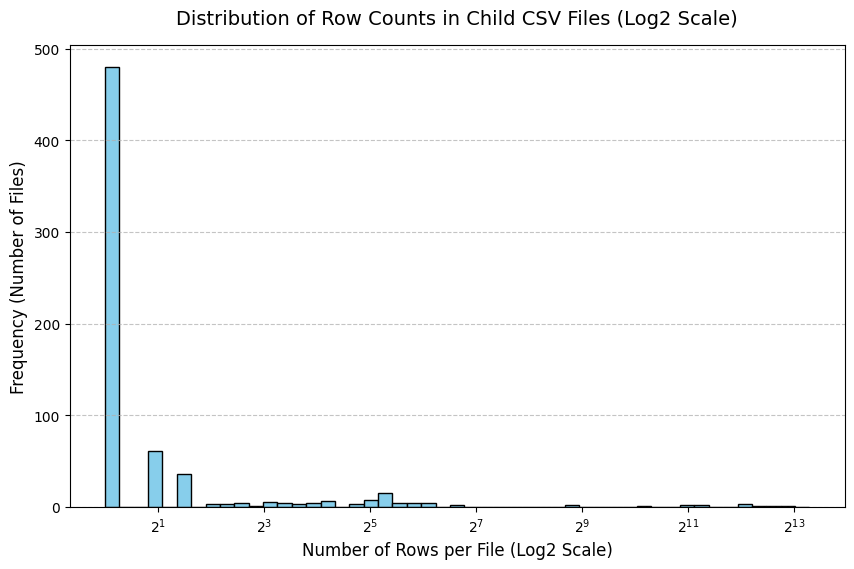

--- Row Count Summary Statistics ---
count      743.00
mean      1099.27
std       3074.61
min          1.00
25%          1.00
50%          1.00
75%          3.00
max      10000.00

Files with at least 32 rows: 125


In [26]:
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import random

# # We use 'my_dataframe' and 'target_csv_path' which were defined in previous cells
# df = my_dataframe

# # 1. Define columns needed for grouping and the final output
# grouping_cols = ['dataset', 'antigen_sequence']
# cols_to_keep = ['universal_id', 'dataset', 'affinity_type', 'confidence']
# MAX_ROWS = 10000

# # Check if all necessary columns exist in the in-memory dataframe
# all_required_cols = set(grouping_cols + cols_to_keep)
# missing_cols = [col for col in all_required_cols if col not in df.columns]

# if missing_cols:
#     print(f"Error: The following required columns are missing from the DataFrame: {missing_cols}")
# else:
#     # 2. Set up the output directory and the zero-padded subdirectories
#     base_dir = os.path.dirname(target_csv_path) 
#     output_subdir = os.path.join(base_dir, "split_csv_2")
    
#     # Create the main directory and the zero-padded subdirectories ("001" through "010")
#     for i in range(1, 11):
#         # f"{i:03d}" formats the integer to a 3-digit string with leading zeros
#         os.makedirs(os.path.join(output_subdir, f"{i:03d}"), exist_ok=True)

#     # 3. Perform the nested grouping, chunking, and randomized export
#     total_files_saved = 0
#     row_counts = []  # In-memory tracker for the histogram
    
#     # Step A: Group by dataset
#     for dataset_name, dataset_df in df.groupby('dataset'):
#         safe_dataset = str(dataset_name).replace('/', '_').replace('\\', '_')
        
#         # Step B: Group by antigen_sequence WITHIN the current dataset
#         grouped_antigens = dataset_df.groupby('antigen_sequence')
        
#         for sequence_number, (antigen_seq, group_df) in enumerate(grouped_antigens, start=1):
            
#             num_rows = len(group_df)
            
#             if num_rows <= MAX_ROWS:
#                 # Randomly select a subdirectory ("001" to "010") for standard export
#                 random_subdir = f"{random.randint(1, 10):03d}"
                
#                 filename = f"{safe_dataset}_{sequence_number}.csv"
#                 output_file = os.path.join(output_subdir, random_subdir, filename)
                
#                 group_df[cols_to_keep].to_csv(output_file, index=False)
                
#                 total_files_saved += 1
#                 row_counts.append(num_rows)
#             else:
#                 # Chunking export for groups over the limit
#                 for batch_idx, start_row in enumerate(range(0, num_rows, MAX_ROWS), start=1):
#                     chunk_df = group_df.iloc[start_row : start_row + MAX_ROWS]
#                     chunk_size = len(chunk_df)
                    
#                     # Randomly select a subdirectory ("001" to "010") for each chunked file
#                     random_subdir = f"{random.randint(1, 10):03d}"
                    
#                     filename = f"{safe_dataset}_{sequence_number}_part{batch_idx}.csv"
#                     output_file = os.path.join(output_subdir, random_subdir, filename)
                    
#                     chunk_df[cols_to_keep].to_csv(output_file, index=False)
                    
#                     total_files_saved += 1
#                     row_counts.append(chunk_size)
                    
#     print(f"Success! Split into {total_files_saved} files randomly distributed across 10 subdirectories (001-010) inside:")
#     print(f"'{output_subdir}'\n")

#     # 4. Generate the Log2 Histogram
#     if row_counts:
#         print("Generating row count distribution histogram...")
        
#         min_val = max(min(row_counts), 1) 
#         max_val = max(row_counts)
        
#         plt.figure(figsize=(10, 6))
        
#         if min_val == max_val:
#             plt.hist(row_counts, bins=1, color='skyblue', edgecolor='black')
#         else:
#             log_bins = np.logspace(np.log2(min_val), np.log2(max_val), num=50, base=2.0)
#             plt.hist(row_counts, bins=log_bins, color='skyblue', edgecolor='black')
        
#         plt.xscale('log', base=2)
        
#         plt.title('Distribution of Row Counts in Child CSV Files (Log2 Scale)', fontsize=14, pad=15)
#         plt.xlabel('Number of Rows per File (Log2 Scale)', fontsize=12)
#         plt.ylabel('Frequency (Number of Files)', fontsize=12)
#         plt.grid(axis='y', alpha=0.75, linestyle='--')
        
#         plt.show()
        
#         counts_series = pd.Series(row_counts)
#         print("--- Row Count Summary Statistics ---")
#         print(counts_series.describe().round(2).to_string())
        
#         # 5. Print the number of files with at least 32 rows
#         files_32_or_more = (counts_series >= 32).sum()
#         print(f"\nFiles with at least 32 rows: {files_32_or_more}")